In [1]:
!pip install monai -q
!pip install albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.5 MB/s eta 0:00:0000:0100:01


In [2]:
from pathlib import Path
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


IMAGE_DIR = Path("/kaggle/input/datasets/triduongduc/cubs-dataset/CUBS_Dataset/images")
TRAIN_MASK_DIR = Path("/kaggle/input/datasets/triduongduc/cubs-dataset/CUBS_Dataset/masks")
VAL_MASK_DIR = Path("/kaggle/input/datasets/triduongduc/cubs-dataset/CUBS_Dataset/GT_masks")


def get_image_id(mask_path: Path):
    return mask_path.stem.replace("_mask", "")


def read_ids(mask_dir: Path):
    ids = []

    for mask_path in sorted(mask_dir.glob("*_mask.png")):
        img_id = get_image_id(mask_path)
        img_path = IMAGE_DIR / f"{img_id}.tiff"

        if img_path.exists():
            ids.append(img_id)

    return ids


def crop_by_mask_x(image, mask):
    binary_mask = (mask > 127).astype(np.uint8)

    cols = np.where(binary_mask.any(axis=0))[0]

    if len(cols) == 0:
        return None, None

    x_min = cols[0]
    x_max = cols[-1]

    image = image[:, x_min:x_max + 1]
    mask = binary_mask[:, x_min:x_max + 1]

    return image, mask


class CUBSDataset(Dataset):
    def __init__(self, image_ids, mask_dir, crop_train_mask=False, transform=None):
        self.image_ids = image_ids
        self.mask_dir = Path(mask_dir)
        self.crop_train_mask = crop_train_mask
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]

        img_path = IMAGE_DIR / f"{img_id}.tiff"
        mask_path = self.mask_dir / f"{img_id}_mask.png"

        image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        if self.crop_train_mask:
            image, mask = crop_by_mask_x(image, mask)

            if image is None or mask is None:
                raise ValueError(f"Empty mask: {mask_path}")

        else:
            mask = (mask > 127).astype(np.uint8)

        if self.transform:
            out = self.transform(image=image, mask=mask)
            image, mask = out["image"], out["mask"]

        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image.astype(np.float32)).unsqueeze(0) / 255.0

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).long()

        return image, mask


In [3]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    # ── 1. Resize & Pad ──────────────────────────────────────────
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(
        min_height=512, min_width=512,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
    ),

    # ── 2. Geometric (nhẹ - carotid có hướng giải phẫu) ─────────
    A.HorizontalFlip(p=0.5),                    # chụp trái/phải cổ

    A.ShiftScaleRotate(
        shift_limit=0.08,   # ±8%  
        scale_limit=0.15,   # ±15%
        rotate_limit=15,    # ±15° 
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
        p=0.5,
    ),

    # Elastic – giả lập lực ép đầu dò lên mô mềm (biên dạng nhẹ)
    A.ElasticTransform(
        alpha=125, sigma=5,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
        p=0.6,
    ),

    # ── 3. Ultrasound artifact ───────────────────────────────────
    A.GaussianBlur(blur_limit=(3, 5)),      # depth-of-field blur

    # ── 4. Intensity – giả lập Gain / TGC / preset máy ──────────
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.2,
    ),
    A.RandomGamma(gamma_limit=(80, 120), p=0.2),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),

    # ── 5. Normalize & Tensor ────────────────────────────────────
    A.Normalize(normalization="min_max"),
    ToTensorV2(),
])


val_transform = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(
        min_height=512, min_width=512,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
    ),
    A.Normalize(normalization="min_max"),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
batch_size  = 8
num_workers = 1
train_ids = read_ids(TRAIN_MASK_DIR)
val_ids = read_ids(VAL_MASK_DIR)

train_ds = CUBSDataset(
    image_ids=train_ids,
    mask_dir=TRAIN_MASK_DIR,
    crop_train_mask=True,
    transform=train_transform,
)

val_ds = CUBSDataset(
    image_ids=val_ids,
    mask_dir=VAL_MASK_DIR,
    crop_train_mask=False,
    transform=val_transform,
)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

print(f"train={len(train_ds)} | val={len(val_ds)}")


train=500 | val=100


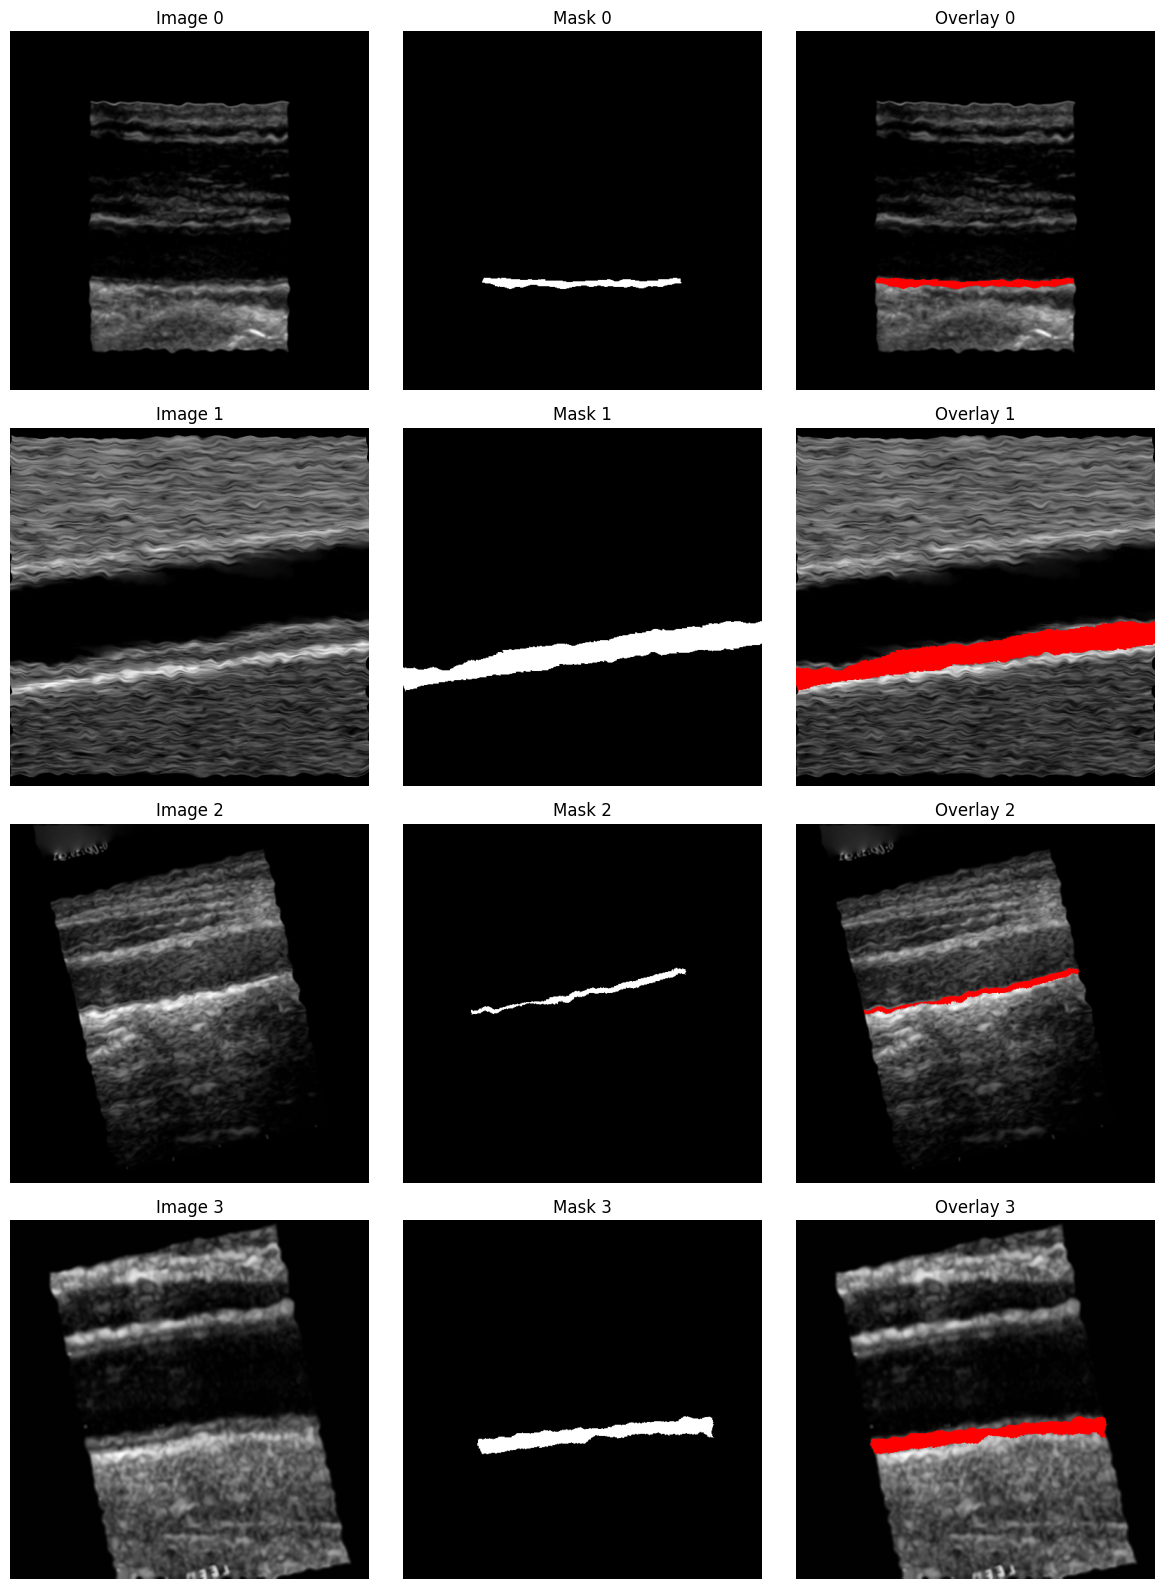

In [5]:
import matplotlib.pyplot as plt
import torch
import numpy as np


def to_numpy_image(x):
    """
    Convert image tensor/numpy về dạng H x W để hiển thị.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()

        if x.ndim == 3:
            # C x H x W -> H x W
            if x.shape[0] == 1:
                x = x.squeeze(0)
            else:
                x = x.permute(1, 2, 0)

        x = x.numpy()

    x = np.asarray(x)

    if x.max() <= 1.0:
        x = x * 255.0

    return x.astype(np.uint8)


def to_numpy_mask(y):
    """
    Convert mask tensor/numpy về dạng H x W.
    """
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu()

        if y.ndim == 3:
            y = y.squeeze(0)

        y = y.numpy()

    return np.asarray(y).astype(np.uint8)


def visualize_train_loader(train_loader, num_images=4):
    """
    Trực quan hóa image, mask và overlay từ train_loader.
    """
    images, masks = next(iter(train_loader))

    num_images = min(num_images, len(images))

    plt.figure(figsize=(12, num_images * 4))

    for i in range(num_images):
        image = to_numpy_image(images[i])
        mask = to_numpy_mask(masks[i])

        overlay = np.stack([image, image, image], axis=-1)
        overlay[mask > 0] = [255, 0, 0]

        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Image {i}")
        plt.axis("off")

        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(mask, cmap="gray")
        plt.title(f"Mask {i}")
        plt.axis("off")

        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_train_loader(train_loader, num_images=4)

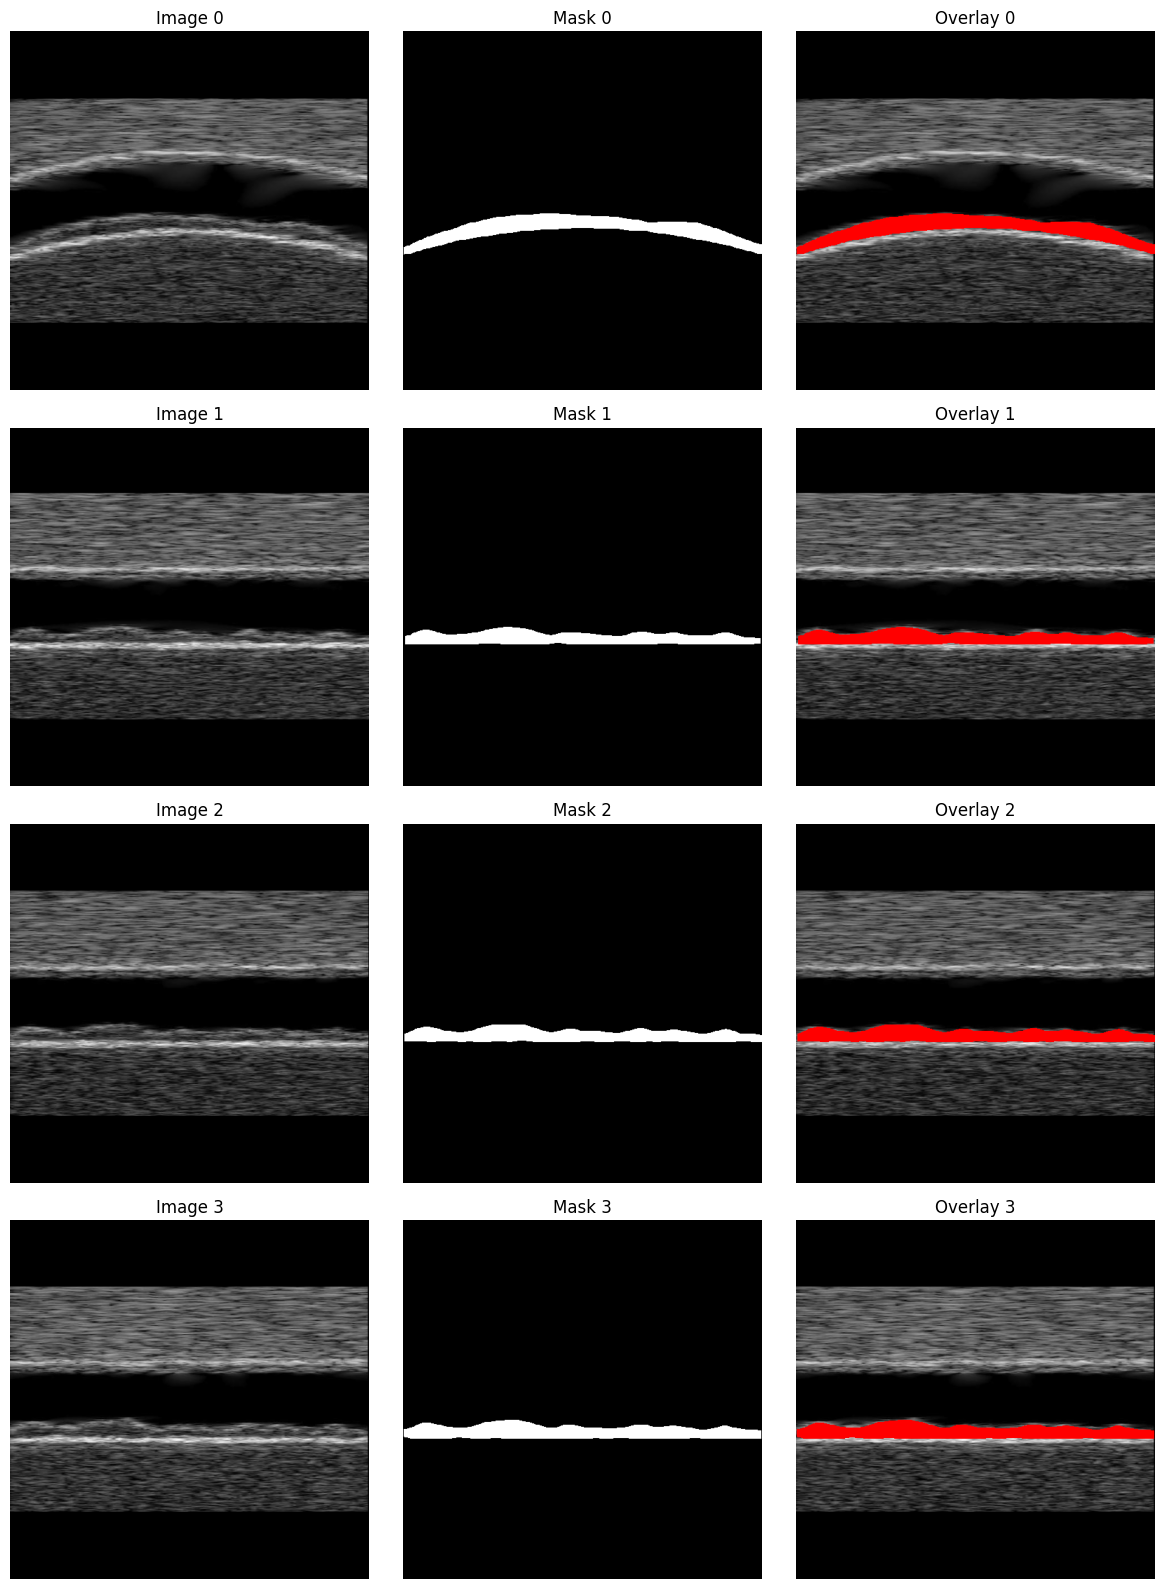

In [6]:
visualize_train_loader(val_loader, num_images=4)

In [7]:
def check_val_loader(val_loader, num_batches=3):
    print("===== CHECK VAL LOADER =====")

    for batch_idx, (images, masks) in enumerate(val_loader):
        print(f"\nBatch {batch_idx + 1}")

        print("images shape:", images.shape)
        print("masks shape :", masks.shape)

        print("images dtype:", images.dtype)
        print("masks dtype :", masks.dtype)

        print("images min :", images.min().item())
        print("images max :", images.max().item())

        print("masks min  :", masks.min().item())
        print("masks max  :", masks.max().item())

        print("mask unique values:", torch.unique(masks))

        if batch_idx + 1 >= num_batches:
            break

check_val_loader(val_loader, num_batches=3)

===== CHECK VAL LOADER =====

Batch 1
images shape: torch.Size([8, 1, 512, 512])
masks shape : torch.Size([8, 512, 512])
images dtype: torch.float64
masks dtype : torch.uint8
images min : 0.0
images max : 0.9999996062993676
masks min  : 0
masks max  : 1
mask unique values: tensor([0, 1], dtype=torch.uint8)

Batch 2
images shape: torch.Size([8, 1, 512, 512])
masks shape : torch.Size([8, 512, 512])
images dtype: torch.float64
masks dtype : torch.uint8
images min : 0.0
images max : 0.9999996047432392
masks min  : 0
masks max  : 1
mask unique values: tensor([0, 1], dtype=torch.uint8)

Batch 3
images shape: torch.Size([8, 1, 512, 512])
masks shape : torch.Size([8, 512, 512])
images dtype: torch.float64
masks dtype : torch.uint8
images min : 0.0
images max : 0.9999996015937842
masks min  : 0
masks max  : 1
mask unique values: tensor([0, 1], dtype=torch.uint8)


In [8]:
from monai.networks.nets.basic_unetplusplus import BasicUNetPlusPlus
from monai.metrics.meandice import DiceMetric
from monai.metrics.meaniou import MeanIoU
from monai.losses.dice import DiceCELoss
from monai.metrics import HausdorffDistanceMetric

from torch import nn
from torch.optim.adamw import AdamW

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-28 09:06:18.502126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777367178.742794      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777367178.815777      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777367179.344901      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777367179.344943      55 computation_placer.cc:1

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from monai.networks.nets.basic_unetplusplus import BasicUNetPlusPlus


class ASPP(nn.Module):
    def __init__(self, channels: int, rates: tuple = (1, 2, 4, 6)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(channels, channels, 3, padding=r, dilation=r, bias=False),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True),
            )
            for r in rates
        ])
        self.global_branch = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(channels * (len(rates) + 1), channels, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h, w = x.shape[2:]
        feats = [b(x) for b in self.branches]
        g = F.interpolate(self.global_branch(x), size=(h, w),
                          mode="bilinear", align_corners=False)
        feats.append(g)
        return self.project(torch.cat(feats, dim=1))


class DilatedUNetPlusPlus(nn.Module):
    """
    Wrapper BasicUNetPlusPlus + ASPP tại bottleneck qua forward hook.
    Hook chặn output của conv_4_0 → thay bằng ASPP(output).
    Toàn bộ forward/dense connections của MONAI chạy bình thường.
    """
    def __init__(self, aspp_rates: tuple = (1, 2, 4, 6), **kwargs):
        super().__init__()
        self.backbone = BasicUNetPlusPlus(**kwargs)

        bottleneck_ch = kwargs.get("features", (32, 32, 64, 128, 256, 32))[4]
        self.aspp = ASPP(channels=bottleneck_ch, rates=aspp_rates)

        # Hook trả về giá trị → PyTorch tự động thay output của conv_4_0
        self._hook = self.backbone.conv_4_0.register_forward_hook(
            self._bottleneck_hook
        )

    def _bottleneck_hook(self, module, input, output):
        return self.aspp(output)   # output cũ bị thay hoàn toàn

    def forward(self, x: torch.Tensor):
        return self.backbone(x)   # MONAI xử lý toàn bộ, hook tự kích hoạt

    def remove_hook(self):
        """Gọi khi cần debug / export ONNX không dùng ASPP."""
        self._hook.remove()

In [10]:
# from monai.networks.nets.swin_unetr import SwinUNETR
# model = SwinUNETR(
#     in_channels=1,
#     out_channels=2,
#     depths=(2, 2, 6, 2),
#     num_heads=(3, 6, 12, 24),
#     feature_size=48,
#     norm_name="instance",
#     drop_rate=0.0,
#     attn_drop_rate=0.0,
#     use_checkpoint=False,
#     spatial_dims=2,
#     patch_norm = True,
#     use_v2= True,
# )

# model = BasicUNetPlusPlus(
#     spatial_dims=2,
#     in_channels=1,
#     out_channels=2,
#     features=(32, 32, 64, 128, 256, 32),
# )

model = DilatedUNetPlusPlus(
    spatial_dims=2,
    in_channels=1,
    out_channels=2,
    features=(32, 32, 64, 128, 256, 32),
    aspp_rates=(1, 2, 4, 8),   # tăng lên (1,2,4,8) nếu cần context rộng hơn
)

# criterion = DiceCELoss(
#         include_background=True,
#         to_onehot_y=True,
#         softmax=True,        # cho multi-class với softmax
#         lambda_dice=2.0,
#         lambda_ce=1.0,
#         jaccard = True,
#     )

from monai.losses import DiceFocalLoss
criterion = DiceFocalLoss(
    include_background=False,
    to_onehot_y=True,
    softmax=True,
    gamma=2.0,        # focal parameter
    lambda_dice=1.0,
    lambda_focal=1.0
)

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10,
    threshold=1e-4,
    cooldown=0,
    min_lr=2e-6,
)

dice_metric = DiceMetric(include_background=False, reduction="mean")
iou_metric  = MeanIoU(include_background=False, reduction="mean")
hd95_metric = HausdorffDistanceMetric(
    include_background=False,
    percentile=95,
    directed=False,
    reduction="mean",
    get_not_nans=False,
)

BasicUNetPlusPlus features: (32, 32, 64, 128, 256, 32).


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device using:", device)

Device using: cuda


In [12]:
from typing import Tuple, Dict, Any, List
from pathlib import Path
import torch
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from tabulate import tabulate
from tqdm import tqdm
import csv


# -------------------------
# Utils
# -------------------------
def to_onehot(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    if labels.dim() == 4:
        labels = labels.squeeze(1)
    return F.one_hot(labels.long(), num_classes).permute(0, 3, 1, 2).float()


def _ensure_mask_shape(masks: torch.Tensor) -> torch.Tensor:
    return masks.unsqueeze(1) if masks.dim() == 3 else masks


def _metric_scalar(val) -> float:
    if isinstance(val, (list, tuple)):
        val = val[0]
    if torch.is_tensor(val):
        val = val.detach().float()
        val = val if val.numel() == 1 else val[torch.isfinite(val)]
        return float("nan") if val.numel() == 0 else float(val.mean().item())
    return float(val)


def _get_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def _onehot_pair(logits, masks, num_classes):
    return (
        to_onehot(torch.argmax(logits, dim=1), num_classes),
        to_onehot(masks.squeeze(1), num_classes),
    )


# -------------------------
# Train / Val 1 epoch
# -------------------------
def train_one_epoch(
    model, loader, optimizer, criterion, num_classes,
    dice_metric, iou_metric, epoch, num_epochs, device,
    use_amp=True, scaler=None,
) -> Tuple[float, float, float]:
    device_type = device.type
    amp_enabled = use_amp and device_type == "cuda"

    model.train()
    dice_metric.reset()
    iou_metric.reset()

    if scaler is None and amp_enabled:
        scaler = GradScaler(device_type, enabled=True)

    running_loss = 0.0
    bar = tqdm(loader, desc=f"Epoch[{epoch}/{num_epochs}] - Train", leave=False)

    for images, masks in bar:
        images = images.to(device, non_blocking=True).float()
        masks  = _ensure_mask_shape(masks.to(device, non_blocking=True).long())

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device_type, enabled=amp_enabled):
            logits = model(images)[0]
            loss   = criterion(logits, masks)

        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()

        with torch.no_grad():
            pred_oh, mask_oh = _onehot_pair(logits, masks, num_classes)
            dice_metric(pred_oh, mask_oh)
            iou_metric(pred_oh, mask_oh)

        bar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{_get_lr(optimizer):.2e}")

    avg_loss = running_loss / max(len(loader), 1)
    return avg_loss, _metric_scalar(dice_metric.aggregate()), _metric_scalar(iou_metric.aggregate())


def test_one_epoch(
    model, loader, criterion, num_classes,
    dice_metric, iou_metric, hd95_metric,
    epoch, num_epochs, device, use_amp=True,
) -> Tuple[float, float, float, float]:
    device_type = device.type
    amp_enabled = use_amp and device_type == "cuda"

    model.eval()
    dice_metric.reset()
    iou_metric.reset()
    hd95_metric.reset()

    running_loss = 0.0
    bar = tqdm(loader, desc=f"Epoch[{epoch}/{num_epochs}] - Val", leave=False)

    with torch.no_grad():
        for images, masks in bar:
            images = images.to(device, non_blocking=True).float()
            masks  = _ensure_mask_shape(masks.to(device, non_blocking=True).long())

            with autocast(device_type=device_type, enabled=amp_enabled):
                outputs = model(images)
                logits  = outputs[0] if isinstance(outputs, (list, tuple)) else outputs
                loss    = criterion(logits, masks)

            running_loss += loss.item()

            pred_oh, mask_oh = _onehot_pair(logits, masks, num_classes)
            dice_metric(pred_oh, mask_oh)
            iou_metric(pred_oh, mask_oh)
            hd95_metric(pred_oh.cpu(), mask_oh.cpu())

            bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / max(len(loader), 1)
    return (
        avg_loss,
        _metric_scalar(dice_metric.aggregate()),
        _metric_scalar(iou_metric.aggregate()),
        _metric_scalar(hd95_metric.aggregate()),
    )


def save_epoch_to_csv(row: dict, csv_path: str):
    p = Path(csv_path)
    p.parent.mkdir(parents=True, exist_ok=True)
    write_header = not p.exists()
    with open(p, mode="a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            w.writeheader()
        w.writerow(row)


# -------------------------
# Full training loop
# -------------------------
def fit(
    model, train_loader, val_loader,
    optimizer, criterion, scheduler,
    dice_metric, iou_metric, hd95_metric,
    num_classes, num_epochs, device,
    use_amp=True,
    save_path="best_model.pt",
    csv_path="training_history.csv",
) -> Dict[str, Any]:
    model = model.to(device)
    amp_enabled = use_amp and device.type == "cuda"
    scaler = GradScaler(device.type, enabled=amp_enabled)

    best_val_dice = -1e9
    history: List[Dict[str, float]] = []
    headers = ["epoch", "lr", "train_loss", "train_dice", "train_iou",
               "val_loss", "val_dice", "val_iou", "val_hd95", "best"]

    for epoch in range(1, num_epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, num_classes,
            dice_metric, iou_metric, epoch, num_epochs, device, use_amp, scaler,
        )
        val_loss, val_dice, val_iou, val_hd95 = test_one_epoch(
            model, val_loader, criterion, num_classes,
            dice_metric, iou_metric, hd95_metric,
            epoch, num_epochs, device, use_amp,
        )

        if scheduler is not None:
            scheduler.step(val_dice)

        is_best = val_dice > best_val_dice
        if is_best:
            best_val_dice = val_dice
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val_dice": best_val_dice,
            }, save_path)

        lr = _get_lr(optimizer)
        print(tabulate(
            [[epoch, f"{lr:.2e}", f"{train_loss:.4f}", f"{train_dice:.4f}", f"{train_iou:.4f}",
              f"{val_loss:.4f}", f"{val_dice:.4f}", f"{val_iou:.4f}", f"{val_hd95:.4f}",
              "Save" if is_best else ""]],
            headers=headers, tablefmt="github",
        ))

        log = dict(epoch=epoch, lr=lr,
                   train_loss=train_loss, train_dice=train_dice, train_iou=train_iou,
                   val_loss=val_loss, val_dice=val_dice, val_iou=val_iou, val_hd95=val_hd95,
                   best_val_dice=best_val_dice, is_best=int(is_best))
        history.append(log)
        save_epoch_to_csv(log, csv_path)

    return {"best_val_dice": best_val_dice, "history": history, "save_path": save_path}

In [13]:
checkpoint = torch.load("/kaggle/working/best_model_dilated.pt", map_location=device)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)

In [14]:
result = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    dice_metric=dice_metric,
    iou_metric=iou_metric,
    hd95_metric=hd95_metric,
    num_classes=2,
    num_epochs=50,
    device=device,
    use_amp=True,
    save_path="/kaggle/working/best_model_dilated.pt",
    csv_path="/kaggle/working/training_history_dilated.csv",
)

Epoch[1/50] - Val:   0%|          | 0/13 [00:00<?, ?it/s]                                     /usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|       1 | 0.0001 |       0.8983 |         0.74 |      0.6018 |     0.7744 |      0.827 |    0.7064 |    18.2635 | Save   |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|       2 | 0.0001 |       0.8589 |       0.7448 |      0.6065 |     0.7335 |     0.8021 |    0.6704 |    12.8062 |        |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|       3 | 0.0001 |        0.828 |       0.7423 |      0.6032 |     0.6843 |     0.8075 |    0.6778 |    29.2074 |        |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|       4 | 0.0001 |       0.7936 |       0.7494 |      0.6124 |     0.6433 |     0.7988 |    0.6662 |    149.189 |        |


...

|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|      22 | 0.0001 |       0.2233 |       0.8605 |      0.7601 |     0.1513 |     0.8809 |    0.7884 |     4.7308 |        |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|      23 | 0.0001 |       0.2134 |       0.8618 |      0.7618 |     0.1554 |     0.8773 |    0.7842 |      4.242 |        |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|      24 | 0.0001 |        0.202 |       0.8651 |      0.7665 |      0.142 |     0.8857 |    0.7969 |     4.2238 |        |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 | best   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|--------|
|      25 | 0.0001 |       0.1974 |       0.8641 |      0.7654 |     0.1391 |     0.8846 |    0.7943 |     4.6321 |        |


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_training_curves(
    csv_path="/kaggle/working/training_history.csv",
    save_dir="/kaggle/working/plots",
    save_fig=True,
):
    csv_path = Path(csv_path)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(csv_path)

    print("CSV columns:", df.columns.tolist())
    print(df.tail())

    # =========================
    # 1. Loss curve
    # =========================
    plt.figure(figsize=(8, 5))

    if "train_loss" in df.columns:
        plt.plot(df["epoch"], df["train_loss"], marker="o", label="Train Loss")

    if "val_loss" in df.columns:
        plt.plot(df["epoch"], df["val_loss"], marker="o", label="Val Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_fig:
        plt.savefig(save_dir / "loss_curve.png", dpi=300)

    plt.show()

    # =========================
    # 2. Dice curve
    # =========================
    plt.figure(figsize=(8, 5))

    if "train_dice" in df.columns:
        plt.plot(df["epoch"], df["train_dice"], marker="o", label="Train Dice")

    if "val_dice" in df.columns:
        plt.plot(df["epoch"], df["val_dice"], marker="o", label="Val Dice")

    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Training / Validation Dice")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_fig:
        plt.savefig(save_dir / "dice_curve.png", dpi=300)

    plt.show()

    # =========================
    # 3. HD95 curve
    # =========================
    plt.figure(figsize=(8, 5))

    if "train_hd95" in df.columns:
        plt.plot(df["epoch"], df["train_hd95"], marker="o", label="Train HD95")

    if "val_hd95" in df.columns:
        plt.plot(df["epoch"], df["val_hd95"], marker="o", label="Val HD95")

    plt.xlabel("Epoch")
    plt.ylabel("HD95")
    plt.title("HD95 Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_fig:
        plt.savefig(save_dir / "hd95_curve.png", dpi=300)

    plt.show()

    # =========================
    # 4. Dice vs HD95
    # =========================
    if "val_dice" in df.columns and "val_hd95" in df.columns:
        plt.figure(figsize=(8, 5))

        plt.plot(df["epoch"], df["val_dice"], marker="o", label="Val Dice")
        plt.plot(df["epoch"], df["val_hd95"], marker="o", label="Val HD95")

        plt.xlabel("Epoch")
        plt.title("Val Dice vs Val HD95")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_fig:
            plt.savefig(save_dir / "dice_hd95_curve.png", dpi=300)

        plt.show()


plot_training_curves(
    csv_path="/kaggle/working/training_history_dilated.csv",
    save_dir="/kaggle/working/plots_dilated",
    save_fig=True,
)

In [ ]:
# ============================================================
# COMPLETE CLEAN INFERENCE SCRIPT
# Case:
#   masks:  tech_401_mask.png -> tech_500_mask.png
#   images: tech_0.tiff       -> tech_500.tiff
#
# Logic:
#   - If mask_folder exists:
#       loop by mask files
#       extract ID from mask
#       find image with same ID
#       show: image, mask_gt, mask_pred, overlay
#       compute: Dice, IoU, HD95 by MONAI
#
#   - If mask_folder does not exist:
#       loop by image files
#       show: image, mask_pred, overlay
#       no metrics
# ============================================================

import os
import re
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F

from pathlib import Path

from monai.metrics import DiceMetric, MeanIoU, compute_hausdorff_distance


# ============================================================
# CONFIG
# ============================================================
IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]


# ============================================================
# FILE HELPERS
# ============================================================
def list_image_files(folder, recursive=False):
    folder = Path(folder)

    if not folder.exists():
        return []

    files = []

    for ext in IMAGE_EXTS:
        if recursive:
            files.extend(folder.rglob(f"*{ext}"))
            files.extend(folder.rglob(f"*{ext.upper()}"))
        else:
            files.extend(folder.glob(f"*{ext}"))
            files.extend(folder.glob(f"*{ext.upper()}"))

    return sorted(list(set(files)))


def extract_last_number_id(path):
    """
    Extract the last number from filename.

    Examples:
        tech_401_mask.png -> 401
        tech_401.tiff     -> 401
        image_000401.png  -> 401
    """

    stem = Path(path).stem
    numbers = re.findall(r"\d+", stem)

    if len(numbers) == 0:
        return None

    return int(numbers[-1])


def build_image_id_map(image_files):
    """
    Build mapping:
        image_id -> image_path

    Example:
        401 -> /images/tech_401.tiff
    """

    image_id_map = {}

    for image_path in image_files:
        image_id = extract_last_number_id(image_path)

        if image_id is None:
            continue

        if image_id not in image_id_map:
            image_id_map[image_id] = image_path

    return image_id_map


# ============================================================
# READ IMAGE / MASK
# ============================================================
def read_image(image_path):
    """
    Read image as RGB or grayscale.
    """

    image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

    if image is None:
        raise ValueError(f"Cannot read image: {image_path}")

    if image.ndim == 2:
        return image

    if image.shape[2] == 4:
        image = image[:, :, :3]

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image


def read_mask(mask_path, num_classes=2):
    """
    Read segmentation mask as class-id mask.

    Binary case:
        0 / 255 -> 0 / 1
    """

    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

    if mask is None:
        raise ValueError(f"Cannot read mask: {mask_path}")

    if mask.ndim == 3:
        if np.all(mask[:, :, 0] == mask[:, :, 1]) and np.all(mask[:, :, 1] == mask[:, :, 2]):
            mask = mask[:, :, 0]
        else:
            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)

    mask = mask.astype(np.uint8)

    if num_classes == 2:
        mask = (mask > 0).astype(np.uint8)

    return mask


def to_uint8_image(image):
    """
    Convert image to uint8 for visualization.
    Works with grayscale, RGB, uint16, float images.
    """

    if image.dtype == np.uint8:
        return image

    image = image.astype(np.float32)
    image = image - image.min()
    image = image / (image.max() + 1e-7)
    image = (image * 255).astype(np.uint8)

    return image


# ============================================================
# PREPROCESS
# Same as:
#   A.LongestMaxSize(max_size=512)
#   A.PadIfNeeded(min_height=512, min_width=512, fill=0)
# ============================================================
def preprocess_longest_pad(image, target_size=512):
    """
    Resize image with longest side = target_size,
    then center pad to target_size x target_size.
    """

    orig_h, orig_w = image.shape[:2]

    scale = target_size / max(orig_h, orig_w)
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))

    resized = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    pad_h = target_size - new_h
    pad_w = target_size - new_w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    if resized.ndim == 2:
        padded = cv2.copyMakeBorder(
            resized,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_CONSTANT,
            value=0
        )
    else:
        padded = cv2.copyMakeBorder(
            resized,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_CONSTANT,
            value=(0, 0, 0)
        )

    meta = {
        "orig_h": orig_h,
        "orig_w": orig_w,
        "new_h": new_h,
        "new_w": new_w,
        "pad_top": pad_top,
        "pad_left": pad_left,
        "target_size": target_size,
    }

    return padded, meta


def minmax_normalize(image, eps=1e-7):
    image = image.astype(np.float32)
    image = (image - image.min()) / (image.max() - image.min() + eps)
    return image


def image_to_tensor(image, in_channels=1):
    """
    Convert image to tensor [1, C, H, W].
    """

    if in_channels == 1:
        if image.ndim == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        image = image[..., None]

    elif in_channels == 3:
        if image.ndim == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    else:
        raise ValueError("in_channels only supports 1 or 3.")

    image = minmax_normalize(image)

    tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float()

    return tensor


# ============================================================
# MODEL OUTPUT HELPERS
# ============================================================
def unwrap_model_output(output):
    """
    Support different output formats:
        tensor
        dict: {'out': tensor}
        tuple/list from deep supervision
    """

    if isinstance(output, dict):
        if "out" in output:
            output = output["out"]
        else:
            output = list(output.values())[0]

    while isinstance(output, (tuple, list)):
        output = output[0]

    if output.ndim == 3:
        output = output.unsqueeze(1)

    if output.ndim != 4:
        raise ValueError(f"Model output must be [B, C, H, W], got shape: {output.shape}")

    return output


def restore_logits_to_original(logits, meta):
    """
    Restore logits from padded 512x512 space to original image size.

    Steps:
        1. Resize logits to target_size if needed.
        2. Crop padding area.
        3. Resize logits to original image size.
    """

    target_size = meta["target_size"]
    new_h = meta["new_h"]
    new_w = meta["new_w"]
    pad_top = meta["pad_top"]
    pad_left = meta["pad_left"]
    orig_h = meta["orig_h"]
    orig_w = meta["orig_w"]

    if logits.shape[-2:] != (target_size, target_size):
        logits = F.interpolate(
            logits,
            size=(target_size, target_size),
            mode="bilinear",
            align_corners=False
        )

    logits = logits[
        :,
        :,
        pad_top:pad_top + new_h,
        pad_left:pad_left + new_w
    ]

    logits = F.interpolate(
        logits,
        size=(orig_h, orig_w),
        mode="bilinear",
        align_corners=False
    )

    return logits


def logits_to_mask(logits, threshold=0.5):
    """
    Binary model:
        logits [1, 1, H, W] -> sigmoid -> threshold

    Multiclass model:
        logits [1, C, H, W] -> argmax
    """

    with torch.no_grad():
        if logits.shape[1] == 1:
            prob = torch.sigmoid(logits)
            pred_mask = (prob > threshold).long()
            pred_mask = pred_mask.squeeze(0).squeeze(0).cpu().numpy()
        else:
            pred_mask = torch.argmax(logits, dim=1)
            pred_mask = pred_mask.squeeze(0).cpu().numpy()

    return pred_mask.astype(np.uint8)


# ============================================================
# MONAI METRICS
# ============================================================
def safe_float(x):
    try:
        if torch.is_tensor(x):
            x = x.detach().cpu().numpy()

        x = float(np.asarray(x).reshape(-1)[0])

        if np.isinf(x):
            return np.nan

        return x

    except Exception:
        return np.nan


def compute_monai_metrics(
    pred_mask,
    gt_mask,
    num_classes=2,
    include_background=False,
    ignore_empty=True,
    spacing=None,
):
    """
    Compute Dice, IoU, HD95 using MONAI.

    Notes:
        - Metrics are computed on original image size.
        - HD95 is pixel-based if spacing=None.
        - If you know physical spacing, use spacing=(dy, dx).
    """

    rows = []

    start_cls = 0 if include_background else 1

    for cls in range(start_cls, num_classes):
        pred_bin = (pred_mask == cls).astype(np.uint8)
        gt_bin = (gt_mask == cls).astype(np.uint8)

        pred_pixels = int(pred_bin.sum())
        gt_pixels = int(gt_bin.sum())

        if ignore_empty and gt_pixels == 0:
            rows.append({
                "class": cls,
                "dice": np.nan,
                "iou": np.nan,
                "hd95": np.nan,
                "gt_pixels": gt_pixels,
                "pred_pixels": pred_pixels,
            })
            continue

        pred_t = torch.from_numpy(pred_bin).unsqueeze(0).unsqueeze(0).float()
        gt_t = torch.from_numpy(gt_bin).unsqueeze(0).unsqueeze(0).float()

        # Dice
        dice_metric = DiceMetric(
            include_background=True,
            reduction="mean",
            ignore_empty=ignore_empty
        )
        dice_metric(y_pred=pred_t, y=gt_t)
        dice = safe_float(dice_metric.aggregate())
        dice_metric.reset()

        # IoU
        iou_metric = MeanIoU(
            include_background=True,
            reduction="mean",
            ignore_empty=ignore_empty
        )
        iou_metric(y_pred=pred_t, y=gt_t)
        iou = safe_float(iou_metric.aggregate())
        iou_metric.reset()

        # HD95
        if pred_pixels > 0 and gt_pixels > 0:
            hd95 = compute_hausdorff_distance(
                y_pred=pred_t,
                y=gt_t,
                include_background=True,
                percentile=95,
                directed=False,
                spacing=spacing,
            )
            hd95 = safe_float(hd95)
        else:
            hd95 = np.nan

        rows.append({
            "class": cls,
            "dice": dice,
            "iou": iou,
            "hd95": hd95,
            "gt_pixels": gt_pixels,
            "pred_pixels": pred_pixels,
        })

    return rows


def summarize_image_metrics(metric_rows):
    """
    Mean metrics across foreground classes.
    For binary segmentation, this is class 1 metric.
    """

    if metric_rows is None or len(metric_rows) == 0:
        return {
            "dice": np.nan,
            "iou": np.nan,
            "hd95": np.nan,
        }

    summary = {}

    for key in ["dice", "iou", "hd95"]:
        values = [row[key] for row in metric_rows if not np.isnan(row[key])]
        summary[key] = float(np.mean(values)) if len(values) > 0 else np.nan

    return summary


# ============================================================
# VISUALIZATION
# ============================================================
def create_overlay(image, mask, alpha=0.45, num_classes=2):
    image = to_uint8_image(image)

    if image.ndim == 2:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    else:
        image_rgb = image.copy()

    color_map = np.array([
        [0, 0, 0],
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [255, 255, 0],
        [255, 0, 255],
        [0, 255, 255],
        [255, 128, 0],
        [128, 0, 255],
        [0, 128, 255],
    ], dtype=np.uint8)

    if num_classes > len(color_map):
        np.random.seed(42)
        extra = np.random.randint(
            0,
            255,
            size=(num_classes - len(color_map), 3),
            dtype=np.uint8
        )
        color_map = np.concatenate([color_map, extra], axis=0)

    mask_safe = mask.copy()
    mask_safe[mask_safe >= len(color_map)] = 0

    color_mask = color_map[mask_safe]

    overlay = image_rgb.copy()
    fg = mask_safe > 0

    overlay[fg] = cv2.addWeighted(
        image_rgb[fg],
        1 - alpha,
        color_mask[fg],
        alpha,
        0
    )

    return overlay


def fmt_metric(x, digits=4):
    if x is None or np.isnan(x):
        return "nan"
    return f"{x:.{digits}f}"


def make_panel(
    image,
    pred_mask,
    overlay,
    gt_mask=None,
    metrics=None,
    num_classes=2,
    title="",
):
    image = to_uint8_image(image)

    if metrics is not None:
        metric_text = (
            f"Dice: {fmt_metric(metrics['dice'])} | "
            f"IoU: {fmt_metric(metrics['iou'])} | "
            f"HD95: {fmt_metric(metrics['hd95'])}"
        )
    else:
        metric_text = ""

    if gt_mask is not None:
        fig = plt.figure(figsize=(22, 5))

        ax1 = plt.subplot(1, 4, 1)
        ax1.imshow(image, cmap="gray" if image.ndim == 2 else None)
        ax1.set_title("Image")
        ax1.axis("off")

        ax2 = plt.subplot(1, 4, 2)
        ax2.imshow(gt_mask, cmap="gray", vmin=0, vmax=num_classes - 1)
        ax2.set_title("Mask GT")
        ax2.axis("off")

        ax3 = plt.subplot(1, 4, 3)
        ax3.imshow(pred_mask, cmap="gray", vmin=0, vmax=num_classes - 1)
        ax3.set_title("Mask Pred")
        ax3.axis("off")

        ax4 = plt.subplot(1, 4, 4)
        ax4.imshow(overlay)
        ax4.set_title("Overlay")
        ax4.axis("off")

    else:
        fig = plt.figure(figsize=(17, 5))

        ax1 = plt.subplot(1, 3, 1)
        ax1.imshow(image, cmap="gray" if image.ndim == 2 else None)
        ax1.set_title("Image")
        ax1.axis("off")

        ax2 = plt.subplot(1, 3, 2)
        ax2.imshow(pred_mask, cmap="gray", vmin=0, vmax=num_classes - 1)
        ax2.set_title("Mask Pred")
        ax2.axis("off")

        ax3 = plt.subplot(1, 3, 3)
        ax3.imshow(overlay)
        ax3.set_title("Overlay")
        ax3.axis("off")

    full_title = title

    if metric_text:
        full_title += "\n" + metric_text

    plt.suptitle(full_title, fontsize=13)
    plt.tight_layout()

    return fig


def show_result(
    image,
    pred_mask,
    overlay,
    gt_mask=None,
    metrics=None,
    num_classes=2,
    title="",
):
    fig = make_panel(
        image=image,
        gt_mask=gt_mask,
        pred_mask=pred_mask,
        overlay=overlay,
        metrics=metrics,
        num_classes=num_classes,
        title=title,
    )

    plt.show()
    plt.close(fig)


# ============================================================
# SINGLE IMAGE INFERENCE
# ============================================================
def inference_one_image(
    model,
    image_path,
    mask_path=None,
    device="cuda",
    target_size=512,
    in_channels=1,
    num_classes=2,
    threshold=0.5,
    include_background=False,
    ignore_empty=True,
    spacing=None,
):
    image_path = Path(image_path)

    image = read_image(image_path)
    orig_h, orig_w = image.shape[:2]

    padded_image, meta = preprocess_longest_pad(
        image=image,
        target_size=target_size
    )

    x = image_to_tensor(
        padded_image,
        in_channels=in_channels
    ).to(device)

    with torch.inference_mode():
        output = model(x)
        logits = unwrap_model_output(output)
        logits = restore_logits_to_original(logits, meta)
        pred_mask = logits_to_mask(logits, threshold=threshold)

    overlay = create_overlay(
        image=image,
        mask=pred_mask,
        alpha=0.45,
        num_classes=num_classes
    )

    gt_mask = None
    metric_rows = None
    image_metrics = None

    if mask_path is not None and Path(mask_path).exists():
        gt_mask = read_mask(mask_path, num_classes=num_classes)

        if gt_mask.shape[:2] != (orig_h, orig_w):
            gt_mask = cv2.resize(
                gt_mask,
                (orig_w, orig_h),
                interpolation=cv2.INTER_NEAREST
            )

        metric_rows = compute_monai_metrics(
            pred_mask=pred_mask,
            gt_mask=gt_mask,
            num_classes=num_classes,
            include_background=include_background,
            ignore_empty=ignore_empty,
            spacing=spacing,
        )

        image_metrics = summarize_image_metrics(metric_rows)

    return {
        "image": image,
        "gt_mask": gt_mask,
        "pred_mask": pred_mask,
        "overlay": overlay,
        "metric_rows": metric_rows,
        "image_metrics": image_metrics,
    }


# ============================================================
# FOLDER INFERENCE
# ============================================================
def inference_folder(
    model,
    image_folder,
    mask_folder=None,
    output_dir="inference_outputs",
    device="cuda",
    target_size=512,
    in_channels=1,
    num_classes=2,
    threshold=0.5,
    include_background=False,
    ignore_empty=True,
    spacing=None,
    show=True,
    show_max=10,
    save_outputs=True,
    save_panels=True,
    recursive_images=False,
    recursive_masks=True,
    verbose=True,
):
    """
    Folder inference.

    If mask_folder exists:
        - Use mask files as main list.
        - Extract ID from mask.
        - Find image with same ID.
        - Compute Dice, IoU, HD95.

    If mask_folder does not exist:
        - Use all image files.
        - No metrics.
    """

    image_folder = Path(image_folder)
    output_dir = Path(output_dir)

    if isinstance(device, str):
        if device.startswith("cuda") and not torch.cuda.is_available():
            print("CUDA is not available. Using CPU instead.")
            device = "cpu"

    device = torch.device(device)

    model = model.to(device)
    model.eval()

    image_files = list_image_files(image_folder, recursive=recursive_images)

    if len(image_files) == 0:
        raise ValueError(f"No images found in: {image_folder}")

    # --------------------------------------------------------
    # Check GT mode
    # --------------------------------------------------------
    use_gt = False
    mask_files = []

    if mask_folder is not None:
        mask_folder = Path(mask_folder)

        if mask_folder.exists() and mask_folder.is_dir():
            mask_files = list_image_files(mask_folder, recursive=recursive_masks)

            if len(mask_files) > 0:
                use_gt = True
            else:
                use_gt = False
                if verbose:
                    print(f"mask_folder exists but no mask files found: {mask_folder}")
        else:
            use_gt = False
            if verbose:
                print(f"mask_folder does not exist. Run without GT metrics: {mask_folder}")

    # --------------------------------------------------------
    # Build image-mask pairs
    # --------------------------------------------------------
    process_items = []

    if use_gt:
        image_id_map = build_image_id_map(image_files)
        missing_images = []

        for mask_path in mask_files:
            mask_id = extract_last_number_id(mask_path)

            if mask_id is None:
                missing_images.append(mask_path.name)
                continue

            image_path = image_id_map.get(mask_id, None)

            if image_path is None:
                missing_images.append(mask_path.name)
                continue

            process_items.append({
                "id": mask_id,
                "image_path": image_path,
                "mask_path": mask_path,
            })

        process_items = sorted(process_items, key=lambda x: x["id"])

        if verbose:
            print(f"Found images: {len(image_files)}")
            print(f"Found masks: {len(mask_files)}")
            print(f"Matched image-mask pairs by ID: {len(process_items)}")

        if len(missing_images) > 0:
            print("\n===== WARNING: Some masks do not have matched images =====")
            print(f"Missing images: {len(missing_images)} / {len(mask_files)}")
            print("First missing examples:", missing_images[:10])

        if len(process_items) == 0:
            raise ValueError("No matched image-mask pairs found. Please check filename IDs.")

    else:
        for image_path in image_files:
            image_id = extract_last_number_id(image_path)

            process_items.append({
                "id": image_id,
                "image_path": image_path,
                "mask_path": None,
            })

        process_items = sorted(
            process_items,
            key=lambda x: -1 if x["id"] is None else x["id"]
        )

        if verbose:
            print(f"Found images: {len(image_files)}")
            print("GT mode: OFF")

    # --------------------------------------------------------
    # Output folders
    # --------------------------------------------------------
    pred_dir = output_dir / "pred_masks"
    overlay_dir = output_dir / "overlays"
    panel_dir = output_dir / "panels"

    if save_outputs:
        pred_dir.mkdir(parents=True, exist_ok=True)
        overlay_dir.mkdir(parents=True, exist_ok=True)

    if save_panels:
        panel_dir.mkdir(parents=True, exist_ok=True)

    image_rows = []
    class_rows = []

    # --------------------------------------------------------
    # Inference loop
    # --------------------------------------------------------
    for idx, item in enumerate(process_items):
        file_id = item["id"]
        image_path = item["image_path"]
        mask_path = item["mask_path"]

        result = inference_one_image(
            model=model,
            image_path=image_path,
            mask_path=mask_path,
            device=device,
            target_size=target_size,
            in_channels=in_channels,
            num_classes=num_classes,
            threshold=threshold,
            include_background=include_background,
            ignore_empty=ignore_empty,
            spacing=spacing,
        )

        image = result["image"]
        gt_mask = result["gt_mask"]
        pred_mask = result["pred_mask"]
        overlay = result["overlay"]
        metric_rows = result["metric_rows"]
        image_metrics = result["image_metrics"]

        has_gt = gt_mask is not None

        row = {
            "id": file_id,
            "image": image_path.name,
            "image_path": str(image_path),
            "mask": mask_path.name if mask_path is not None else None,
            "mask_path": str(mask_path) if mask_path is not None else None,
            "has_ground_truth": has_gt,
            "height": image.shape[0],
            "width": image.shape[1],
            "dice": np.nan,
            "iou": np.nan,
            "hd95": np.nan,
        }

        if image_metrics is not None:
            row["dice"] = image_metrics["dice"]
            row["iou"] = image_metrics["iou"]
            row["hd95"] = image_metrics["hd95"]

        image_rows.append(row)

        if metric_rows is not None:
            for r in metric_rows:
                r = r.copy()
                r["id"] = file_id
                r["image"] = image_path.name
                r["image_path"] = str(image_path)
                r["mask"] = mask_path.name if mask_path is not None else None
                r["mask_path"] = str(mask_path) if mask_path is not None else None
                class_rows.append(r)

        # ----------------------------------------------------
        # Save prediction and overlay
        # ----------------------------------------------------
        if save_outputs:
            if num_classes == 2:
                pred_to_save = (pred_mask * 255).astype(np.uint8)
            else:
                pred_to_save = pred_mask.astype(np.uint8)

            pred_save_path = pred_dir / f"{image_path.stem}_pred.png"
            overlay_save_path = overlay_dir / f"{image_path.stem}_overlay.png"

            cv2.imwrite(str(pred_save_path), pred_to_save)
            cv2.imwrite(
                str(overlay_save_path),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR)
            )

        # ----------------------------------------------------
        # Show result
        # ----------------------------------------------------
        if show and idx < show_max:
            title = f"ID: {file_id} | Image: {image_path.name}"

            if mask_path is not None:
                title += f" | Mask: {mask_path.name}"

            show_result(
                image=image,
                gt_mask=gt_mask,
                pred_mask=pred_mask,
                overlay=overlay,
                metrics=image_metrics,
                num_classes=num_classes,
                title=title,
            )

        # ----------------------------------------------------
        # Save panel
        # ----------------------------------------------------
        if save_panels:
            title = f"ID: {file_id} | Image: {image_path.name}"

            if mask_path is not None:
                title += f" | Mask: {mask_path.name}"

            fig = make_panel(
                image=image,
                gt_mask=gt_mask,
                pred_mask=pred_mask,
                overlay=overlay,
                metrics=image_metrics,
                num_classes=num_classes,
                title=title,
            )

            panel_save_path = panel_dir / f"{image_path.stem}_panel.png"
            fig.savefig(str(panel_save_path), dpi=150, bbox_inches="tight")
            plt.close(fig)

    # --------------------------------------------------------
    # DataFrames and CSV
    # --------------------------------------------------------
    image_df = pd.DataFrame(image_rows)
    metric_df = pd.DataFrame(class_rows)

    output_dir.mkdir(parents=True, exist_ok=True)

    image_df.to_csv(output_dir / "image_metrics.csv", index=False)

    if len(metric_df) > 0:
        metric_df.to_csv(output_dir / "class_metrics.csv", index=False)

    # --------------------------------------------------------
    # Print summary
    # --------------------------------------------------------
    if len(metric_df) > 0:
        print("\n===== Per-image metrics =====")
        print(
            image_df[
                ["id", "image", "mask", "has_ground_truth", "dice", "iou", "hd95"]
            ].head(30)
        )

        print("\n===== Mean metrics =====")
        print(image_df[["dice", "iou", "hd95"]].mean(skipna=True))

        print("\n===== Mean metrics per class =====")
        print(
            metric_df
            .groupby("class")[["dice", "iou", "hd95", "gt_pixels", "pred_pixels"]]
            .mean(numeric_only=True)
        )

    else:
        print("\nNo GT masks found. Metrics were not computed.")

    return image_df, metric_df


# ============================================================
# RUN WITH GT MASKS
# ============================================================
image_df, metric_df = inference_folder(
    model=model,

    image_folder="/kaggle/input/datasets/triduongduc/cubs-dataset/CUBS_Dataset/images",
    mask_folder="/kaggle/input/datasets/triduongduc/cubs-dataset/CUBS_Dataset/GT_masks",

    output_dir="/kaggle/working/inference_outputs",

    device="cuda",
    target_size=512,
    in_channels=1,
    num_classes=2,
    threshold=0.5,

    include_background=False,
    ignore_empty=True,

    # spacing=None: HD95 tính theo pixel.
    # Nếu biết spacing thực tế, ví dụ spacing=(0.1, 0.1), thì điền vào đây.
    spacing=None,

    show=True,
    show_max=10,

    save_outputs=True,
    save_panels=True,

    recursive_images=False,
    recursive_masks=True,
    verbose=True,
)